# Dataset Loading

In [1]:
# Install required packages
!pip install --quiet contractions
!pip install --quiet wordcloud
!pip install --quiet gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00


In [2]:
# ── Core Libraries 
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling
import numpy as np
import pandas as pd

# ── Visualisation 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP Utilities 
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

# ── Sklearn 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

# ── Keras / TensorFlow 
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print("\n All libraries loaded successfully.")

2026-05-10 06:04:10.455679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778393050.668551      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778393050.735076      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778393051.213013      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778393051.213074      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778393051.213077      23 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
NumPy       : 2.0.2
Pandas      : 2.3.3

 All libraries loaded successfully.


# Data Preprocessing

In [3]:
# ── List available input files 
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ozzzz2/news-category/news_category.csv


In [4]:
# ── Load the dataset 
DATA_PATH = "/kaggle/input/datasets/ozzzz2/news-category/news_category.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head(10)

Dataset shape : (11025, 2)
Columns       : ['headline', 'category']


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


# Dataset Visualization

In [5]:
# ── Basic dataset statistics
print("DATASET OVERVIEW")
print(f"Total samples      : {len(df)}")
print(f"Missing headlines  : {df['headline'].isna().sum()}")
print(f"Missing categories : {df['category'].isna().sum()}")
print(f"Unique categories  : {df['category'].nunique()}")
print("\nCategory distribution:")
print(df['category'].value_counts())

DATASET OVERVIEW
Total samples      : 11025
Missing headlines  : 0
Missing categories : 0
Unique categories  : 5

Category distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


In [6]:
# ── Drop rows with missing values 
df = df.dropna(subset=['headline', 'category']).reset_index(drop=True)
print(f"Clean dataset shape: {df.shape}")

Clean dataset shape: (11025, 2)


# Simple RNN Model

In [7]:
# ── Initialise NLTK tools
lemmatizer  = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

# ── Individual cleaning functions
def to_lowercase(text: str) -> str: 
    return text.lower()
def expand_contractions(text: str) -> str:
    return contractions.fix(text)
def remove_noise(text: str) -> str:
    
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+',           '', text)   # mentions
    text = re.sub(r'#\w+',           '', text)   # hashtags
    text = re.sub(r'\d+',            '', text)   # numbers
    return text

def remove_special_chars(text: str) -> str:
    return re.sub(r'[^a-z\s]', '', text)

def remove_stopwords(text: str) -> str:
    return ' '.join(word for word in text.split() if word not in STOP_WORDS)

def lemmatize_text(text: str) -> str:
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

# ── Full preprocessing pipeline
def clean_text(text: str) -> str:
    text = to_lowercase(text)
    text = expand_contractions(text)
    text = remove_noise(text)
    text = remove_special_chars(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text.strip()

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [8]:
# ── Apply cleaning pipeline to dataset
print("Cleaning text... (this may take a moment)")
df['cleaned_headline'] = df['headline'].apply(clean_text)

# ── Preview before and after 
print("\nBefore vs After Cleaning")
for i in range(3):
    print(f"\nOriginal : {df['headline'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_headline'].iloc[i]}")

Cleaning text... (this may take a moment)

Before vs After Cleaning

Original : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned  : new documentary capture complexity child immigrant

Original : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Cleaned  : twitch ban gambling site streamer scam folk

Original : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Cleaned  : reboot clever navelgazey look inside tv reboots


# Train Simple RNN

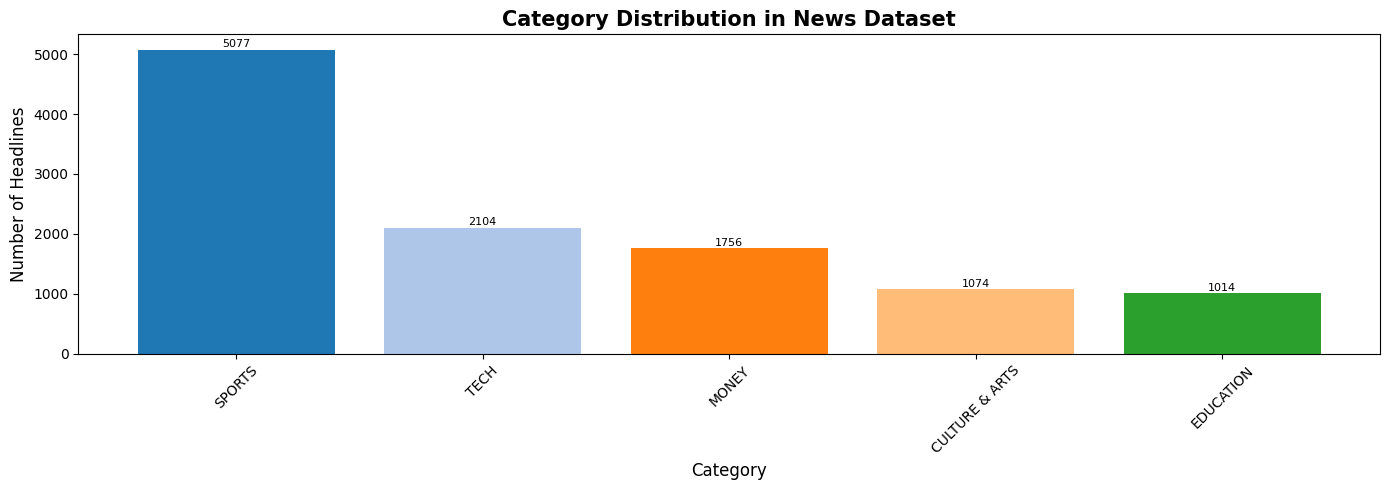


Note: Dataset has 5 unique categories.


In [9]:
# ── 4.1 Category Distribution
fig, ax = plt.subplots(figsize=(14, 5))
category_counts = df['category'].value_counts()
bars = ax.bar(category_counts.index, category_counts.values,
              color=plt.cm.tab20.colors[:len(category_counts)])
ax.set_title('Category Distribution in News Dataset', fontsize=15, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(f"\nNote: Dataset has {df['category'].nunique()} unique categories.")

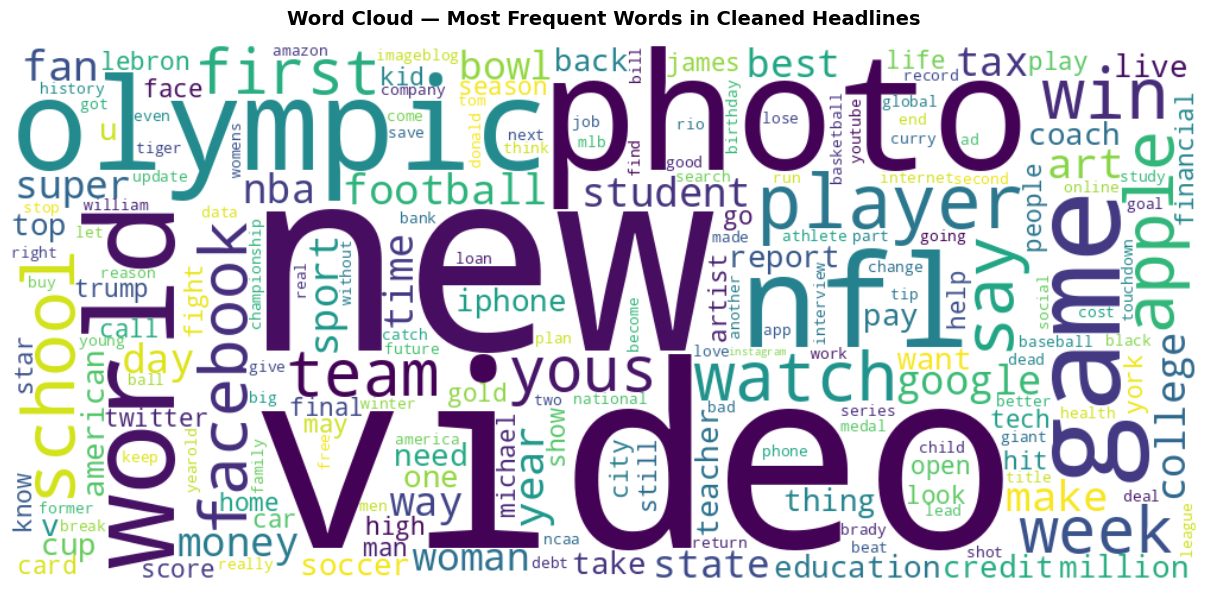

In [10]:
# ── 4.2 Word Cloud of cleaned headlines 
all_words = ' '.join(df['cleaned_headline'].dropna().tolist())

wordcloud = WordCloud(
    width=1000, height=450,
    background_color='white',
    max_words=200,
    colormap='viridis',
    collocations=False
).generate(all_words)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Most Frequent Words in Cleaned Headlines',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Evaluate Simple RNN

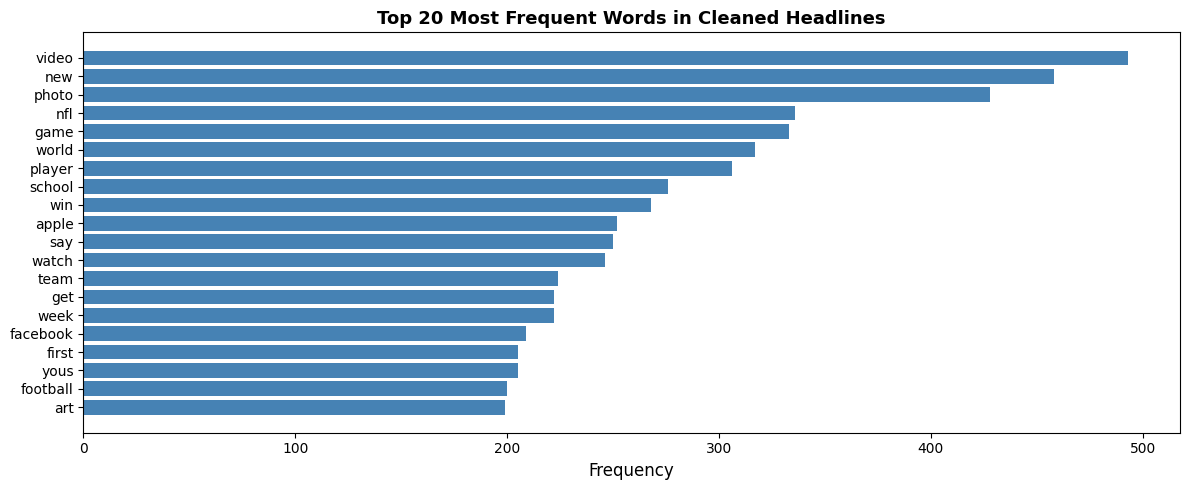

In [11]:
# ── 4.3 Top 20 Most Frequent Words
from collections import Counter

word_counts = Counter(all_words.split())
top_20 = word_counts.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Frequent Words in Cleaned Headlines',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

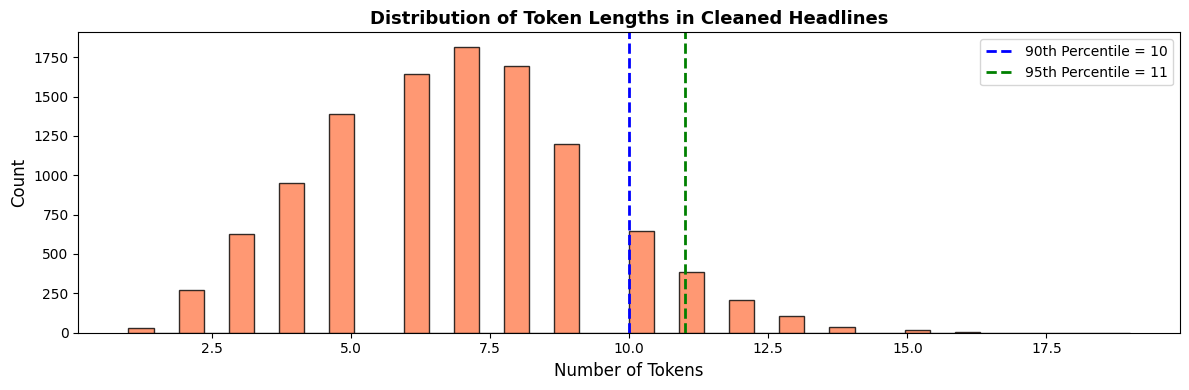

Mean length   : 6.86
Median length : 7
90th pct      : 10  → Using this as MAX_LEN for padding
95th pct      : 11


In [12]:
# ── 4.4 Headline Token Length Distribution
df['token_length'] = df['cleaned_headline'].apply(lambda x: len(str(x).split()))

p90 = int(np.percentile(df['token_length'], 90))
p95 = int(np.percentile(df['token_length'], 95))

plt.figure(figsize=(12, 4))
plt.hist(df['token_length'], bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(p90, color='blue',  linestyle='--', linewidth=2, label=f'90th Percentile = {p90}')
plt.axvline(p95, color='green', linestyle='--', linewidth=2, label=f'95th Percentile = {p95}')
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Token Lengths in Cleaned Headlines', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean length   : {df['token_length'].mean():.2f}")
print(f"Median length : {df['token_length'].median():.0f}")
print(f"90th pct      : {p90}  → Using this as MAX_LEN for padding")
print(f"95th pct      : {p95}")

# Simple RNN Classification Report

In [13]:
# ── Label Encoding 
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

NUM_CLASSES = df['label'].nunique()
print(f"Number of classes : {NUM_CLASSES}")
print(f"Class mapping     :")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i:2d} → {cls}")

Number of classes : 5
Class mapping     :
   0 → CULTURE & ARTS
   1 → EDUCATION
   2 → MONEY
   3 → SPORTS
   4 → TECH


In [14]:
# ── Train / Test Split (80% / 20%)
X = df['cleaned_headline'].astype(str).tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 8820
Testing samples  : 2205


# Simple RNN Confusion Matrix

In [15]:
# ── Tokenisation
VOCAB_SIZE  = 20000  # top 20 000 most frequent words
OOV_TOKEN   = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)            # fit only on training data to avoid data leakage

word_index  = tokenizer.word_index
print(f"Vocabulary size (total unique words) : {len(word_index)}")
print(f"Capped vocabulary used by model      : {VOCAB_SIZE}")

Vocabulary size (total unique words) : 12007
Capped vocabulary used by model      : 20000


In [16]:
# ── Sequence Conversion 
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based Padding Length 
seq_lengths = [len(s) for s in train_sequences]
MAX_LEN = int(np.percentile(seq_lengths, 90))
print(f"Padding MAX_LEN (90th percentile) : {MAX_LEN}")

# ── Padding 
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN,
                             padding='post', truncating='post')
# Convert labels to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

Padding MAX_LEN (90th percentile) : 10
X_train_pad shape : (8820, 10)
X_test_pad  shape : (2205, 10)


# LSTM Model

In [17]:
# ── Shared Hyperparameters
EMBED_DIM   = 64    # embedding vector dimension
RNN_UNITS   = 64    # units in recurrent layer
DROPOUT     = 0.4

# ── Model 1: Simple RNN
model1 = Sequential(name='Simple_RNN')
model1.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBED_DIM,
                     input_length=MAX_LEN,
                     name='embedding_rnn'))
model1.add(SimpleRNN(RNN_UNITS, return_sequences=False, name='simple_rnn'))
model1.add(Dropout(DROPOUT))
model1.add(Dense(64, activation='relu', name='dense_hidden'))
model1.add(Dropout(0.3))
model1.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

I0000 00:00:1778393082.054068      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778393082.060214      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

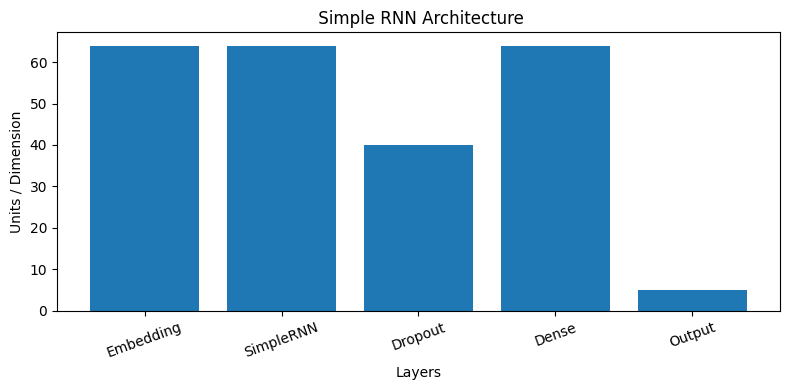

In [18]:
import matplotlib.pyplot as plt

layers = ["Embedding", "SimpleRNN", "Dropout", "Dense", "Output"]
units = [EMBED_DIM, RNN_UNITS, int(DROPOUT * 100), 64, NUM_CLASSES]

plt.figure(figsize=(8, 4))
plt.bar(layers, units)
plt.title(" Simple RNN Architecture")
plt.xlabel("Layers")
plt.ylabel("Units / Dimension")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [19]:
# ── Model 2: LSTM 
model2 = Sequential(name='LSTM_Trainable_Embedding')
model2.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBED_DIM,
                     input_length=MAX_LEN,
                     name='embedding_lstm'))
model2.add(LSTM(RNN_UNITS, return_sequences=False, name='lstm'))
model2.add(Dropout(DROPOUT))
model2.add(Dense(64, activation='relu', name='dense_hidden'))
model2.add(Dropout(0.3))
model2.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

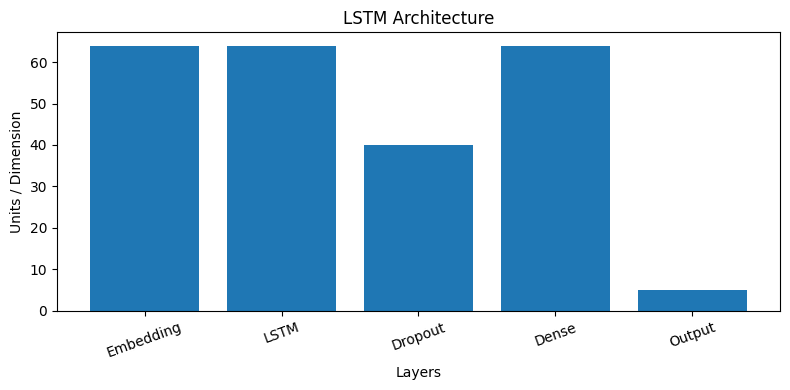

In [20]:
import matplotlib.pyplot as plt

layers = ["Embedding", "LSTM", "Dropout", "Dense", "Output"]
units = [EMBED_DIM, RNN_UNITS, int(DROPOUT * 100), 64, NUM_CLASSES]

plt.figure(figsize=(8, 4))
plt.bar(layers, units)
plt.title("LSTM Architecture")
plt.xlabel("Layers")
plt.ylabel("Units / Dimension")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Train LSTM Model

In [21]:
# ── Install gensim and dependencies
!pip install --quiet gensim

In [22]:
# ── Download pre-trained GloVe embeddings via gensim 
import gensim.downloader as gensim_api

GLOVE_DIM = 50
print("Downloading glove-wiki-gigaword-50 ")
glove_model = gensim_api.load('glove-wiki-gigaword-50')
print("GloVe model loaded.")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe model loaded.


# Evaluate LSTM Model

In [23]:
# ── Build the GloVe embedding matrix 

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hit, miss = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hit += 1
    else:
        miss += 1

coverage = hit / (hit + miss) * 100
print(f"Vocabulary coverage by GloVe: {hit} / {hit+miss} words ({coverage:.1f}%)")

Vocabulary coverage by GloVe: 10782 / 12007 words (89.8%)


In [24]:
# ── Model 3: LSTM + Pre-trained GloVe (frozen) 
model3 = Sequential(name='LSTM_GloVe_Embedding')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],     # initialise with GloVe weights
    input_length=MAX_LEN,
    trainable=False,                 # freeze embeddings — do not update during training
    name='glove_embedding'
))
model3.add(LSTM(RNN_UNITS, return_sequences=False, name='lstm'))
model3.add(Dropout(DROPOUT))
model3.add(Dense(64, activation='relu', name='dense_hidden'))
model3.add(Dropout(0.3))
model3.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

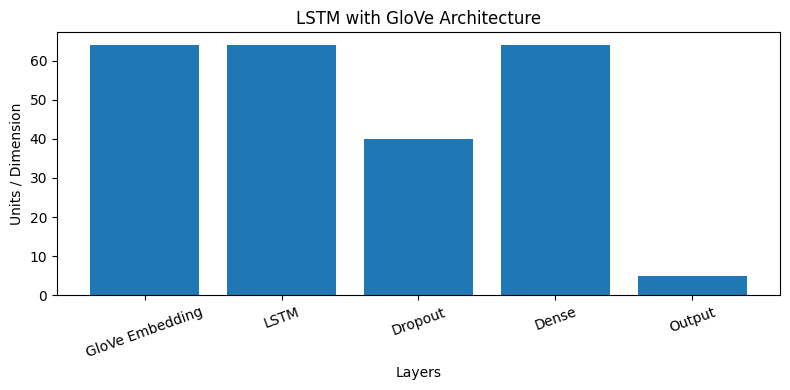

In [25]:
layers = ["GloVe Embedding", "LSTM", "Dropout", "Dense", "Output"]

units = [EMBED_DIM, RNN_UNITS, int(DROPOUT * 100), 64, NUM_CLASSES]

plt.figure(figsize=(8,4))

plt.bar(layers, units)

plt.title("LSTM with GloVe Architecture")
plt.xlabel("Layers")
plt.ylabel("Units / Dimension")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# LSTM Classification Report

In [26]:
# ── Shared Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

EPOCHS     = 20
BATCH_SIZE = 64
VALIDATION = 0.15   

In [27]:
# ── Train Model 1: Simple RNN 

print("Training Model 1 — Simple RNN")


history1 = model1.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 1 — Simple RNN
Epoch 1/20


I0000 00:00:1778393181.423817      90 service.cc:152] XLA service 0x7aaf0800b710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778393181.423865      90 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778393181.423872      90 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778393181.787146      90 cuda_dnn.cc:529] Loaded cuDNN version 91002


 51/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4145 - loss: 1.4780

I0000 00:00:1778393183.811415      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4688 - loss: 1.3385 - val_accuracy: 0.6047 - val_loss: 0.9049 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7202 - loss: 0.6752 - val_accuracy: 0.7460 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8966 - loss: 0.3012 - val_accuracy: 0.7755 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 4/20
106/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9693 - loss: 0.1154
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9692 - loss: 0.1154 - val_accuracy: 0.7642 - val_loss: 0.8430 - learning_rate: 0.0010
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9899 - loss: 0.0462 - val_accuracy: 0.7672 - val_loss: 1.0198 - learning_rate: 5.0000e-04
Epoch 6/20
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9939 - loss: 0.0283
Epoch 6: 

# LSTM Confusion Matrix

In [28]:
# ── Train Model 2: LSTM

print("Training Model 2 — LSTM")
history2 = model2.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 2 — LSTM
Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4597 - loss: 1.4117 - val_accuracy: 0.5956 - val_loss: 0.9291 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6271 - loss: 0.8078 - val_accuracy: 0.7370 - val_loss: 0.7317 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8209 - loss: 0.4635 - val_accuracy: 0.7967 - val_loss: 0.6078 - learning_rate: 0.0010
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9417 - loss: 0.1930 - val_accuracy: 0.8095 - val_loss: 0.6709 - learning_rate: 0.0010
Epoch 5/20
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9684 - loss: 0.1096
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9685 - loss: 0.1095 - val_accuracy: 0.7959 - val_loss: 0.8052 - learning_rate: 0.0010
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0

In [29]:
# ── Train Model 3: LSTM + GloVe 

print("Training Model 3 — LSTM + GloVe Embeddings")
history3 = model3.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 3 — LSTM + GloVe Embeddings
Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4994 - loss: 1.2328 - val_accuracy: 0.7687 - val_loss: 0.6096 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7996 - loss: 0.6076 - val_accuracy: 0.8171 - val_loss: 0.5060 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8335 - loss: 0.4980 - val_accuracy: 0.8360 - val_loss: 0.4695 - learning_rate: 0.0010
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8407 - loss: 0.4951 - val_accuracy: 0.8330 - val_loss: 0.4597 - learning_rate: 0.0010
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8564 - loss: 0.4356 - val_accuracy: 0.8473 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8608 - loss: 0.4343 - val_accuracy: 0.8413 - val_loss: 0.4439 - learning_rate: 0.0010
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7m

# Word2Vec Embedding

In [30]:
def plot_training_history(history, model_name, color='steelblue'):
    """Plot training vs validation accuracy and loss for a single model."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color=color, linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color=color, linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='tomato', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linewidth=2, linestyle='--')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

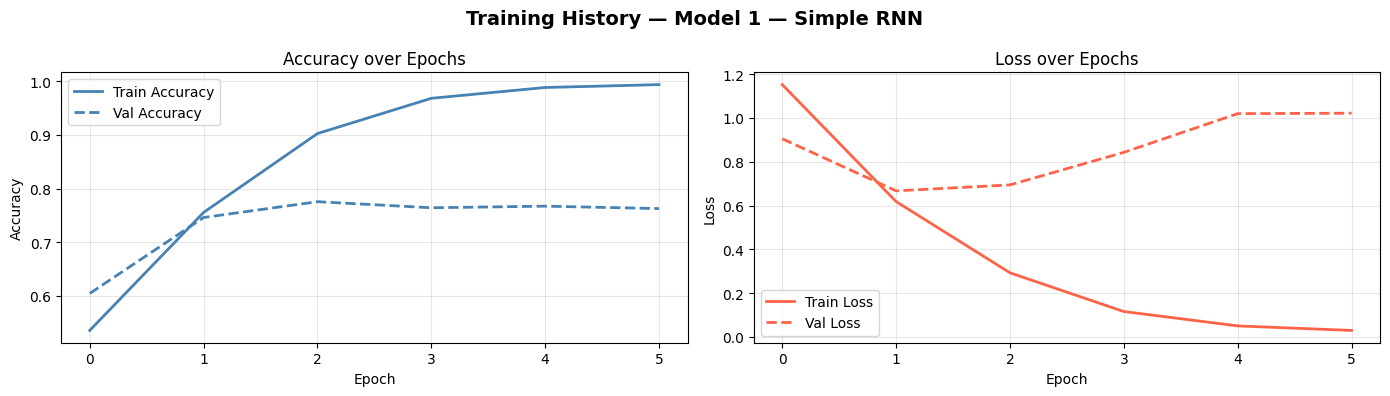

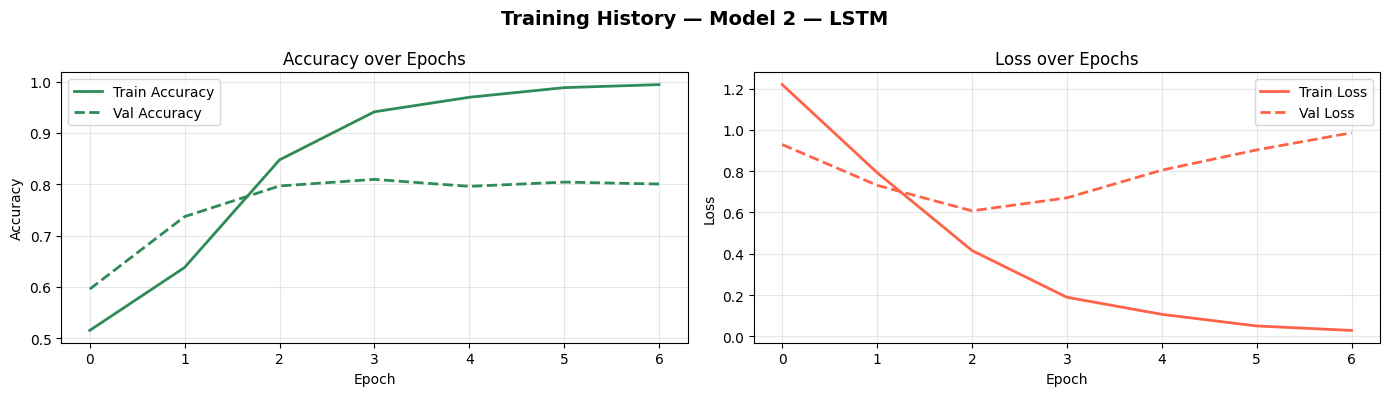

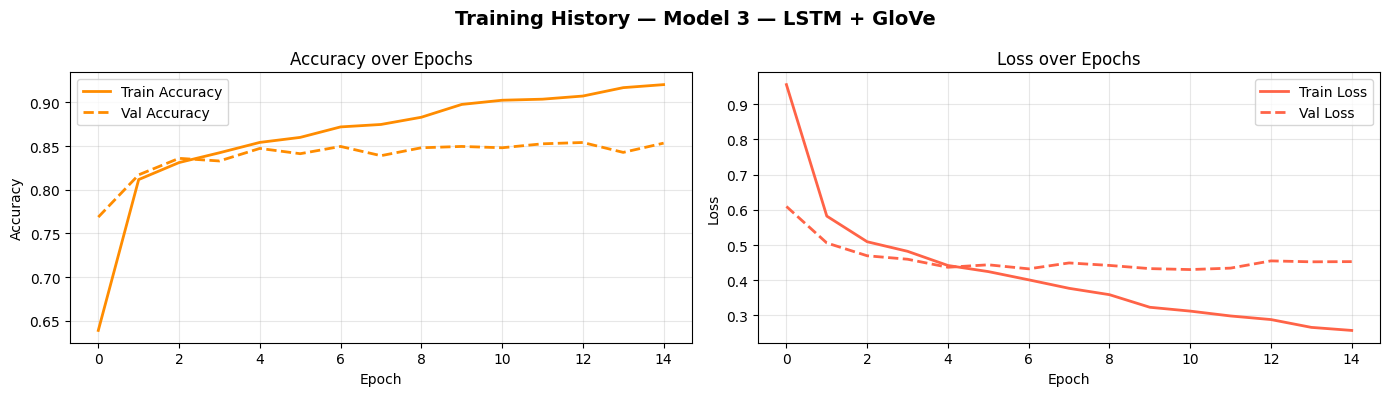

In [31]:
# ── Individual training plots
plot_training_history(history1, 'Model 1 — Simple RNN',        color='steelblue')
plot_training_history(history2, 'Model 2 — LSTM',              color='seagreen')
plot_training_history(history3, 'Model 3 — LSTM + GloVe',      color='darkorange')

# LSTM with Word2Vec

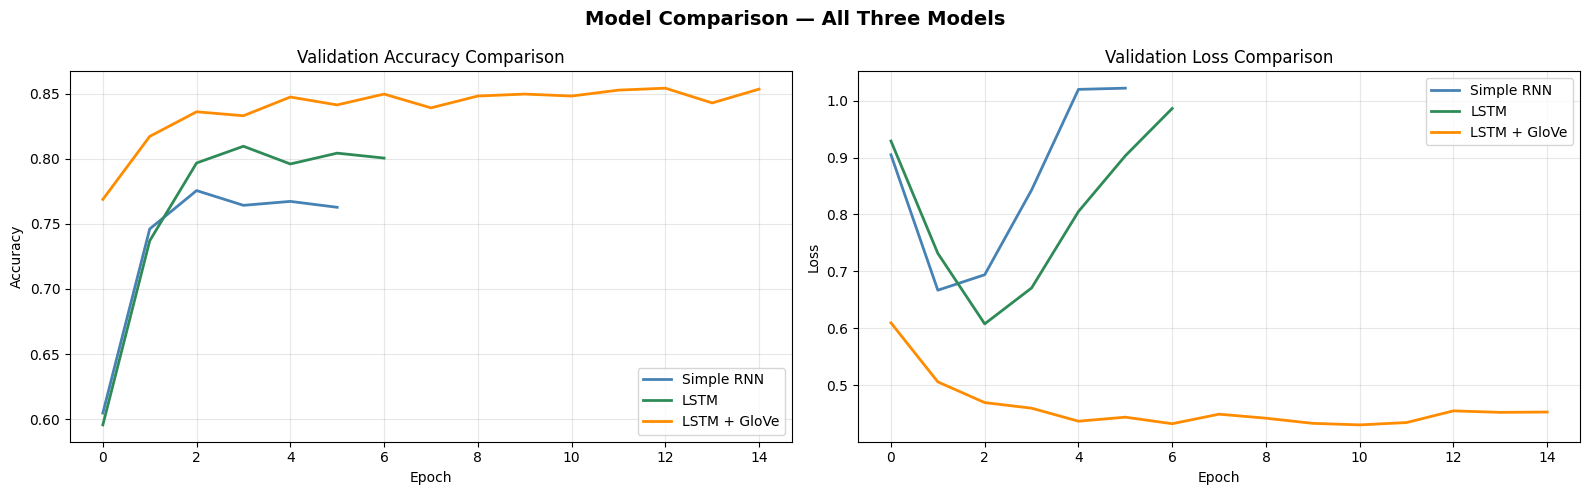

In [32]:
# ── Side-by-side comparison of all 3 models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison — All Three Models', fontsize=14, fontweight='bold')

# Validation Accuracy
axes[0].plot(history1.history['val_accuracy'], label='Simple RNN',    color='steelblue',  linewidth=2)
axes[0].plot(history2.history['val_accuracy'], label='LSTM',          color='seagreen',   linewidth=2)
axes[0].plot(history3.history['val_accuracy'], label='LSTM + GloVe',  color='darkorange', linewidth=2)
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(history1.history['val_loss'], label='Simple RNN',   color='steelblue',  linewidth=2)
axes[1].plot(history2.history['val_loss'], label='LSTM',         color='seagreen',   linewidth=2)
axes[1].plot(history3.history['val_loss'], label='LSTM + GloVe', color='darkorange', linewidth=2)
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
def evaluate_model(model, X_test, y_test, label_encoder, model_name):
    """
    Evaluate a model and print accuracy, classification report,
    and confusion matrix.
    """
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    print(f"Model: {model_name}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation='vertical', cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

# Train Word2Vec Model

Model: Simple RNN
Test Accuracy: 0.7610 (76.10%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.50      0.44      0.47       215
     EDUCATION       0.52      0.58      0.55       203
         MONEY       0.60      0.73      0.66       351
        SPORTS       0.91      0.92      0.91      1015
          TECH       0.83      0.66      0.74       421

      accuracy                           0.76      2205
     macro avg       0.67      0.67      0.66      2205
  weighted avg       0.77      0.76      0.76      2205



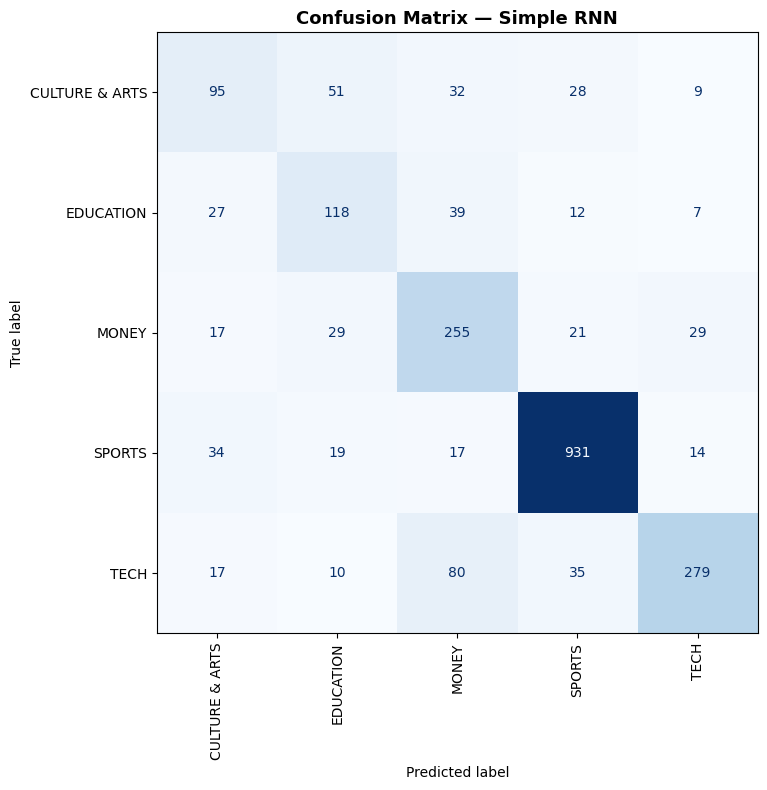

Model: LSTM
Test Accuracy: 0.8168 (81.68%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.61      0.66      0.63       215
     EDUCATION       0.70      0.58      0.63       203
         MONEY       0.76      0.72      0.74       351
        SPORTS       0.93      0.91      0.92      1015
          TECH       0.77      0.86      0.81       421

      accuracy                           0.82      2205
     macro avg       0.75      0.75      0.75      2205
  weighted avg       0.82      0.82      0.82      2205



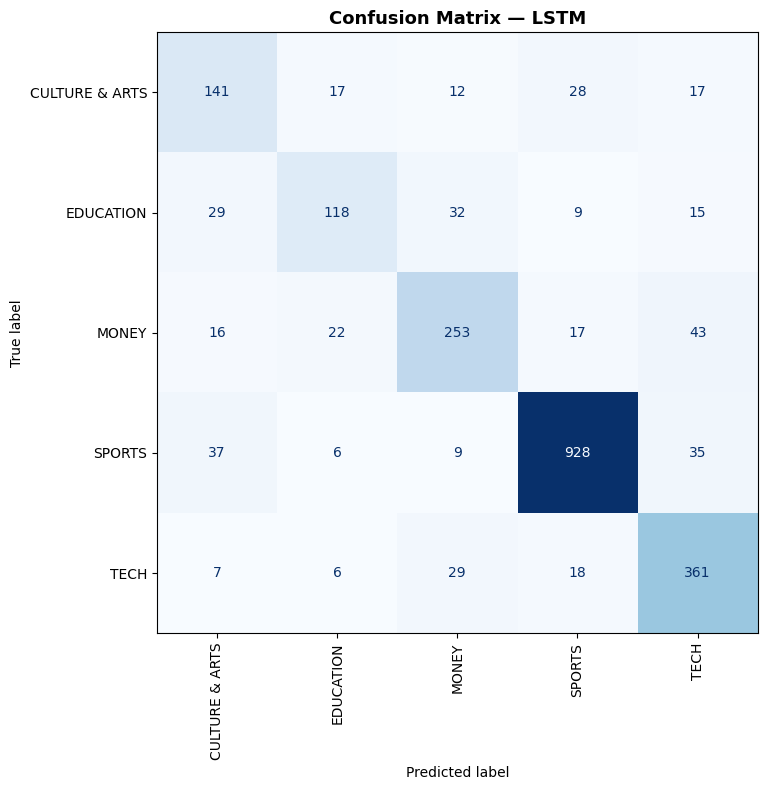

Model: LSTM + GloVe
Test Accuracy: 0.8522 (85.22%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.79      0.77      0.78       215
     EDUCATION       0.73      0.74      0.74       203
         MONEY       0.82      0.77      0.80       351
        SPORTS       0.92      0.93      0.92      1015
          TECH       0.81      0.83      0.82       421

      accuracy                           0.85      2205
     macro avg       0.81      0.81      0.81      2205
  weighted avg       0.85      0.85      0.85      2205



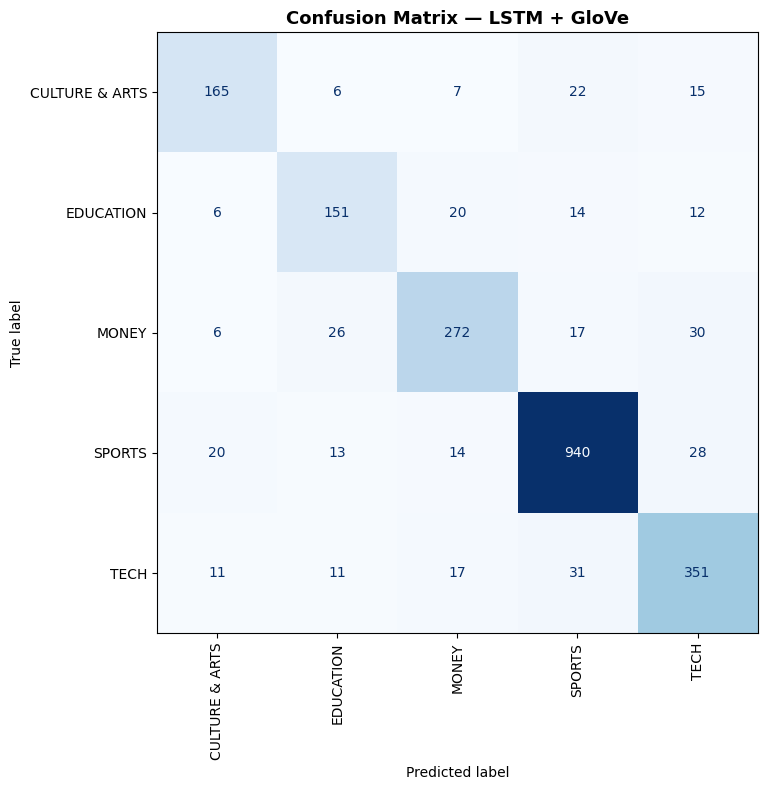

In [34]:
# ── Evaluate all three models
acc1, y_pred1 = evaluate_model(model1, X_test_pad, y_test_arr, label_encoder, 'Simple RNN')
acc2, y_pred2 = evaluate_model(model2, X_test_pad, y_test_arr, label_encoder, 'LSTM')
acc3, y_pred3 = evaluate_model(model3, X_test_pad, y_test_arr, label_encoder, 'LSTM + GloVe')

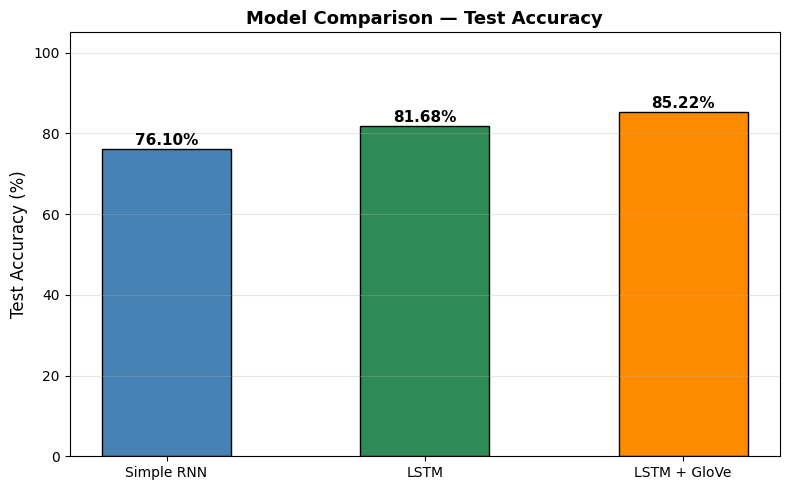

In [35]:
# ── Summary Accuracy Bar Chart 
model_names   = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies    = [acc1, acc2, acc3]
bar_colors    = ['steelblue', 'seagreen', 'darkorange']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [a*100 for a in accuracies], color=bar_colors, width=0.5, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate Word2Vec Model

In [36]:
# ── Find misclassified examples from Model 2 (LSTM) 
# We use the LSTM model as our primary model for error analysis

misclassified_idx = np.where(y_pred2 != y_test_arr)[0]
print(f"Total misclassified by LSTM: {len(misclassified_idx)} / {len(y_test_arr)} "
      f"({len(misclassified_idx)/len(y_test_arr)*100:.1f}%)")
print("MISCLASSIFIED EXAMPLES (first 5)")

for i, idx in enumerate(misclassified_idx[:5]):
    original  = X_test[idx]
    true_lbl  = label_encoder.inverse_transform([y_test_arr[idx]])[0]
    pred_lbl  = label_encoder.inverse_transform([y_pred2[idx]])[0]
    print(f"\nExample {i+1}:")
    print(f"  Headline  : {original}")
    print(f"  True Label: {true_lbl}")
    print(f"  Predicted : {pred_lbl}")

Total misclassified by LSTM: 404 / 2205 (18.3%)
MISCLASSIFIED EXAMPLES (first 5)

Example 1:
  Headline  : judicial negligence compound political negligence south carolina
  True Label: EDUCATION
  Predicted : CULTURE & ARTS

Example 2:
  Headline  : go back grad school
  True Label: MONEY
  Predicted : EDUCATION

Example 3:
  Headline  : social medium con artist
  True Label: TECH
  Predicted : MONEY

Example 4:
  Headline  : robin ramirez amiko fountain marilyn johnson charged running million counterfeit coupon ring
  True Label: MONEY
  Predicted : SPORTS

Example 5:
  Headline  : automatic transfer easily save rainy day
  True Label: MONEY
  Predicted : EDUCATION


In [37]:
# ── Most confused class pairs
cm2 = confusion_matrix(y_test_arr, y_pred2)
np.fill_diagonal(cm2, 0)  # zero out correct predictions

# Find top confused pairs
confused_pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm2[i, j] > 0:
            confused_pairs.append((cm2[i, j],
                                   label_encoder.classes_[i],
                                   label_encoder.classes_[j]))
confused_pairs.sort(reverse=True)

print("Top 10 Most Confused Class Pairs (LSTM Model):")
print(f"{'True Label':<25} {'Predicted As':<25} {'Count':>5}")
for count, true_cls, pred_cls in confused_pairs[:10]:
    print(f"{true_cls:<25} {pred_cls:<25} {count:>5}")

Top 10 Most Confused Class Pairs (LSTM Model):
True Label                Predicted As              Count
MONEY                     TECH                         43
SPORTS                    CULTURE & ARTS               37
SPORTS                    TECH                         35
EDUCATION                 MONEY                        32
TECH                      MONEY                        29
EDUCATION                 CULTURE & ARTS               29
CULTURE & ARTS            SPORTS                       28
MONEY                     EDUCATION                    22
TECH                      SPORTS                       18
MONEY                     SPORTS                       17


# Word2Vec Classification Report

In [38]:
# ── Save trained models
model1.save("model_rnn.keras")
model2.save("model_lstm.keras")
model3.save("model_lstm_word2vec.keras")

# ── Save tokenizer 
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# ── Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# ── Save MAX_LEN for inference
with open("max_len.pkl", "wb") as f:
    pickle.dump(MAX_LEN, f)

print("All models, tokenizer, and encoder saved successfully.")
print(f"   model_rnn.keras             — Simple RNN")
print(f"   model_lstm.keras            — LSTM")
print(f"   model_lstm_word2vec.keras   — LSTM + GloVe")
print(f"   tokenizer.pkl               — Keras Tokenizer")
print(f"   label_encoder.pkl           — Sklearn LabelEncoder")
print(f"   max_len.pkl                 — Padding length ({MAX_LEN})")

All models, tokenizer, and encoder saved successfully.
   model_rnn.keras             — Simple RNN
   model_lstm.keras            — LSTM
   model_lstm_word2vec.keras   — LSTM + GloVe
   tokenizer.pkl               — Keras Tokenizer
   label_encoder.pkl           — Sklearn LabelEncoder
   max_len.pkl                 — Padding length (10)


In [39]:
import gradio as gr
from tensorflow.keras.models import load_model

# ── Reload saved artifacts 
model1_inf = load_model("model_rnn.keras")
model2_inf = load_model("model_lstm.keras")
model3_inf = load_model("model_lstm_word2vec.keras")

with open("tokenizer.pkl", "rb") as f:
    tokenizer_inf = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder_inf = pickle.load(f)
with open("max_len.pkl", "rb") as f:
    MAX_LEN_INF = pickle.load(f)

print(f" Models loaded. MAX_LEN = {MAX_LEN_INF}")

 Models loaded. MAX_LEN = 10


# Word2Vec Confusion Matrix

In [40]:
# ── Preprocessing for inference 
def preprocess_for_inference(text: str) -> np.ndarray:
    """
    Apply the full cleaning pipeline and tokenize/pad a single text input
    ready for model prediction.
    """
    cleaned  = clean_text(text)
    sequence = tokenizer_inf.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN_INF, padding='post', truncating='post')
    return padded


# ── Prediction function
def predict_category(headline: str, model_choice: str) -> str:
    """
    Takes a raw headline string and model choice,
    returns the predicted news category with confidence.
    """
    if not headline.strip():
        return "Please enter a headline."

    processed = preprocess_for_inference(headline)

    model_map = {
        "Simple RNN"        : model1_inf,
        "LSTM"              : model2_inf,
        "LSTM with GloVe"   : model3_inf
    }
    selected_model = model_map[model_choice]

    probs     = selected_model.predict(processed, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    category  = label_encoder_inf.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx] * 100

    # Top 3 predictions
    top3_idx  = np.argsort(probs)[::-1][:3]
    top3_str  = "\n".join(
        f"  {i+1}. {label_encoder_inf.inverse_transform([idx])[0]}: {probs[idx]*100:.1f}%"
        for i, idx in enumerate(top3_idx)
    )

    result = (
        f"Predicted Category : {category}\n"
        f"Confidence         : {confidence:.1f}%\n\n"
        f"Top 3 Predictions:\n{top3_str}"
    )
    return result


# Gradio Interface 
iface = gr.Interface(
    fn=predict_category,
    inputs=[
        gr.Textbox(
            label=" Enter a News Headline",
            lines=3,
            placeholder="e.g. Scientists discover new species in Amazon rainforest..."
        ),
        gr.Radio(
            choices=["Simple RNN", "LSTM", "LSTM with GloVe"],
            label=" Choose Model",
            value="LSTM"
        )
    ],
    outputs=gr.Textbox(label=" Prediction Result", lines=7),
    title=" News Category Classifier",
    description=(
        "Enter a news headline and choose a model to predict its category.\n"
        "Models trained on the News Category dataset using RNN, LSTM, and GloVe embeddings."
    ),
    examples=[
        ["Government announces new budget cuts for education", "LSTM"],
        ["Local football team wins championship in dramatic final", "LSTM with GloVe"],
        ["Apple unveils new iPhone with revolutionary AI features", "Simple RNN"],
        ["New study links diet to mental health outcomes", "LSTM"]
    ],
    allow_flagging='never'
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://23c4e489e2707e9c84.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
